# Does the oil ETF in your brokerage app actually own oil? 🛢️📉
### USO-Roll-Decay — a fund down **80%** while "the price of oil" was flat

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Owns_oil%3F: Busted](https://img.shields.io/badge/Owns_oil%3F-Busted-8b949e?style=flat-square)

Crude oil roughly round-tripped over the last twenty years — the front-month price you see quoted on every news ticker is almost exactly where it started. USO, the biggest retail oil ETF, is down **four-fifths of its value** over the same stretch. Same commodity, same two decades, completely different outcome.

That's the claim we test: *USO doesn't track oil — it tracks a leaky bucket that happens to be shaped like oil.* And on the single most extreme day in oil-market history, it did the opposite of what everyone assumed, too.

> 📓 **Plain-language layer.** Want the *t*-stats, the bootstrap and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** "Oil" here means CL=F, the continuously-rolled NYMEX front-month futures print — the exact number every ticker calls "the price of oil" (no free physical-spot series exists, and this is what the folklore actually means). Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from uso_roll_decay import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    USO, CLF = data.load_real()
    DF = st.gap_frame(USO, CLF)
    STRESS = data.stress_mask(DF.index)
else:
    USO = CLF = DF = STRESS = None
print("real cache present:", HAVE_REAL, "| daily gap obs:", (0 if DF is None else len(DF)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2006-04-11', 'end': '2026-06-30', 'years': 20.22, 'n': 5080, 'tr_uso': -80.5, 'tr_clf': 0.8, 'cagr_uso': -7.76, 'cagr_clf': 0.04, 'cagr_gap': -7.8, 'gap_mean_pct': -0.0362, 'gap_ann_pct': -9.13, 'naive_t': -2.11, 'nw5': -2.33, 'nw21': -1.91, 'nw63': -1.67, 'hit': 2579, 'hit_pct': 50.8, 'wilson': (49.4, 52.1), 'boot_lo': -20.2, 'boot_hi': -1.7, 'boot_p': 0.0038, 'stress_n': 229, 'stress_pct_days': 4.5, 'stress_ann': -155.4, 'stress_t': -2.06, 'rest_n': 4851, 'rest_ann': -2.23, 'rest_t': -0.8, 'welch_stress_rest': -2.03, 'stress_share': 76.7, 'w09_n': 146, 'w09_ann': -61.1, 'w09_t': -0.96, 'w20_n': 83, 'w20_ann': -321.1, 'w20_t': -1.84, 'apr20': [('2020-04-17', 33.68, -3.44, 18.27, -8.05), ('2020-04-20', 30.0, -10.93, -37.63, -305.97), ('2020-04-21', 22.48, -25.07, 10.01, -126.6), ('2020-04-22', 20.08, -10.68, 13.78, 37.66), ('2020-04-23', 21.12, 5.18, 16.5, 19.74)], 'week_dd': -40.4, 'gross_ann': 9.13, 'gross_vol': 19.4, 'gross_sharpe': 0.47, 'gross_dd': -58.8, 'gross_worst': -14.2, 'hac21_t': 1.91, 'placebo_p': 0.013, 'net5_ann': 7.17, 'net5_sharpe': 0.37, 'net5_dd': -62.9, 'net10_ann': 5.97, 'net10_sharpe': 0.31, 'net10_dd': -65.2, 'ex_stress_ann': 0.27, 'ex_stress_sharpe': 0.02, 'stress_only_ann': 153.4, 'stress_only_sharpe': 2.13, 'syn_null_mean': -0.09, 'syn_null_sd': 0.8, 'syn_null_fire': 0, 'syn_planted_naive': -16.31, 'syn_planted_nw5': -7.64, 'fp_uso': 'b9dde5e9cdd0', 'fp_clf': '0e2eae3d2942', 'years_total': 21, 'years_neg': 13, 'years_pos': 8, 'ex2020_n': 4829, 'ex2020_ann': -3.86, 'ex2020_naive_t': -1.15, 'ex2020_nw21_t': -1.92, 'ex2020_boot_lo': -7.8, 'ex2020_boot_hi': -0.11, 'ex2020_boot_p': 0.023, 'post2020_start': '2021-01-04', 'post2020_years': 5.48, 'post2020_n': 1378, 'post2020_tr_uso': 228.7, 'post2020_tr_clf': 45.9, 'post2020_cagr_gap': 17.1, 'post2020_ann': 14.84, 'post2020_naive_t': 2.52, 'post2020_nw21_t': 4.47, 'post2020_boot_lo': 8.72, 'post2020_boot_hi': 21.84, 'post2020_hit_pct': 47.0}


real cache present: True | daily gap obs: 5080


## The answer first

| Question | Answer |
|---|---|
| Does USO actually track the oil price? | **No — not even close.** Over **20 years** USO lost **80%** while the quoted oil price gained **0.8%**. That's a **7.8 percentage-point** annual gap, every year, compounding. |
| Why? | Contango. USO holds oil *futures*, and rolling from an expiring contract to the next one usually means selling cheap and buying dear — a toll a real barrel in a tank never pays. |
| Is the damage spread evenly across 20 years? | **No — it's lumpy.** **77%** of the entire two-decade gap happened in just **4.5%** of trading days — two historic storage crises, 2009 and 2020. |
| What happened the day oil went negative? | USO barely blinked. The front contract crashed to **-$37.63**; USO fell a completely ordinary **-10.9%** that day, because it wasn't fully holding that exact contract. |
| Can you get paid for knowing this? | **Not reliably.** Shorting USO against long oil futures made money on paper — but almost *all* of it came from those same two crises. Miss them and the trade earns roughly nothing. |
| Does the drag keep happening every year? | **No.** Split by calendar year, USO underperformed in **13/21** years — a majority, not a rule — and for the last **5.5 years running** (2021 → 2026) it has done the *opposite*: USO actually **beat** the headline oil price by **+14.8%/yr**. |

> The two crisis episodes really happened and really hurt. But "USO mechanically loses to oil" turns out to describe two storms, not a standing law of physics — the mental model "USO = oil" is wrong in both directions, and so, it turns out, is "USO always loses to oil."

## 1 · The claim

> *"Buy USO, own the oil price."* It's on the tin — United States **Oil** Fund — and it trades on your brokerage app right next to the S&P 500 and gold. Millions of retail investors have bought it expecting exactly that: exposure to crude.

The honest mechanism, steelmanned: USO holds NYMEX WTI **futures contracts**, not barrels in a tank. Every contract expires, so the fund must constantly "roll" — sell the contract about to expire, buy the next month out. When the market is in **contango** (later months cost more than the current one), that roll is mechanically unprofitable, over and over, regardless of what the actual oil price does — but when the curve flips to **backwardation** the exact same roll turns profitable, so how true this is depends entirely on which regime the market is in at the time, not on a fixed law.

## 2 · So what?

If this is real, it means one of the most-traded commodity ETFs in the world systematically misleads its own holders about what they own — and it means the flip side, "short the ETF, capture the toll," might be a genuine, repeatable trade. Billions of retail dollars have flowed through USO since 2006; a structural 80% gap against the thing it's named after is not a footnote.

## 3 · How would we even know?

- **The race.** USO's split-adjusted price vs CL=F (the front-month oil price everyone quotes), 2006-04-11 → 2026-06-30, cumulative and annualized.
- **The daily grind.** Is USO's daily return systematically a little worse than oil's, day after day — and is that reliable, not luck?
- **The regime check.** Is the damage a steady bleed, or does it come from a handful of specific crisis episodes (2009's storage glut, 2020's COVID collapse)?
- **The extreme case.** What actually happened to USO the day oil futures went negative — did the "USO = oil" story hold up when it mattered most?
- **The trade check.** Short USO, go long oil futures, pay realistic costs and borrow — does the obvious trade actually pay, reliably?

## 4 · The teardown — let's actually look

**First, the headline.** Twenty years, same commodity, two completely different lines.

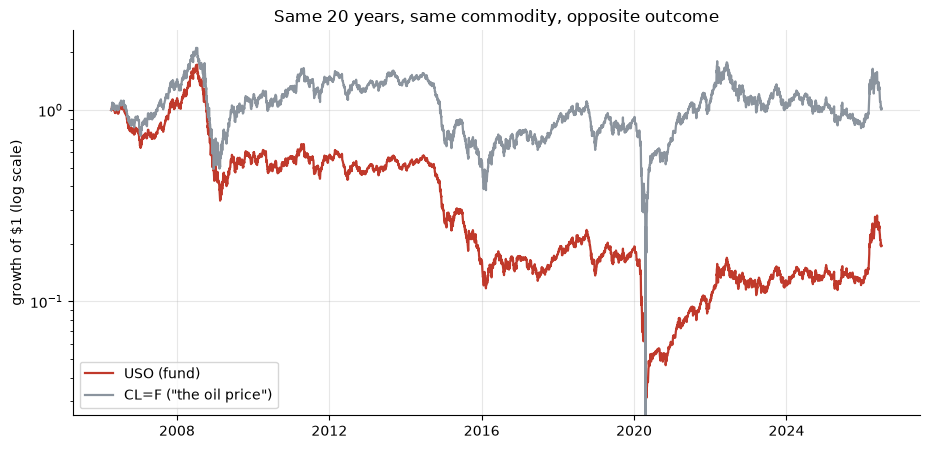

USO total return -80.5%   CL=F total return +0.8%


In [2]:
if HAVE_REAL:
    cs = st.cumulative_stats(DF)
    uso_cum = (1 + USO['Close'].pct_change().fillna(0)).cumprod()
    clf_cum = (1 + CLF['Close'].pct_change().fillna(0)).cumprod()
    tr_u, tr_c = cs['total_return_uso']*100, cs['total_return_clf']*100
else:
    tr_u, tr_c = R['tr_uso'], R['tr_clf']
fig, ax = plt.subplots(figsize=(9.4, 4.6))
if HAVE_REAL:
    ax.plot(uso_cum.index, uso_cum.values, color=RED, lw=1.6, label='USO (fund)')
    ax.plot(clf_cum.index, clf_cum.values, color=GREY, lw=1.6,
            label='CL=F ("the oil price")')
    ax.set_yscale('log'); ax.set_ylabel('growth of $1 (log scale)')
    ax.legend()
else:
    ax.bar(['USO','CL=F ("oil price")'], [tr_u, tr_c], color=[RED, GREY], width=.55)
    for i,v in enumerate([tr_u, tr_c]): ax.annotate(f'{v:+.1f}%',(i,v),ha='center',
        va='top' if v<0 else 'bottom')
    ax.set_ylabel('total return (%)')
ax.set_title('Same 20 years, same commodity, opposite outcome')
plt.tight_layout(); plt.show()
print(f'USO total return {tr_u:+.1f}%   CL=F total return {tr_c:+.1f}%')

USO: **-80.5%**. The oil price: **+0.8%**. That's a **7.80 percentage-point** compounding gap *every single year* for two decades. This isn't a bad year or a bad decade — it's the whole sample.

**Next: is it a steady leak, or does it come in bursts?**

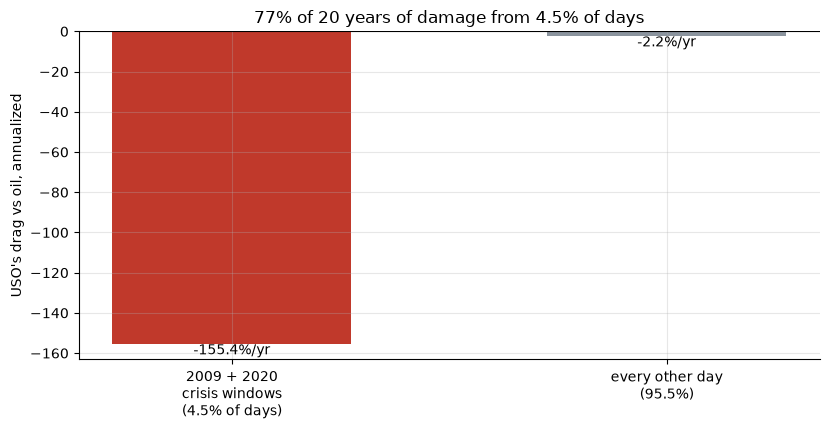

stress windows -155.4%/yr   rest of tape -2.23%/yr


In [3]:
if HAVE_REAL:
    stress_ann = DF.loc[STRESS, 'gap'].mean()*252*100
    rest_ann = DF.loc[~STRESS, 'gap'].mean()*252*100
else:
    stress_ann, rest_ann = R['stress_ann'], R['rest_ann']
fig, ax = plt.subplots(figsize=(8.4, 4.4))
ax.bar(['2009 + 2020\ncrisis windows\n(4.5% of days)','every other day\n(95.5%)'],
       [stress_ann, rest_ann], color=[RED, GREY], width=.55)
for i,v in enumerate([stress_ann, rest_ann]): ax.annotate(f'{v:+.1f}%/yr',(i,v),
    ha='center', va='top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel("USO's drag vs oil, annualized")
ax.set_title(f'{R["stress_share"]:.0f}% of 20 years of damage from 4.5% of days')
plt.tight_layout(); plt.show()
print(f'stress windows {stress_ann:+.1f}%/yr   rest of tape {rest_ann:+.2f}%/yr')

There's the shape of it: during the two named storage crises the drag runs at **-155%/yr**; every other day it's a mild **-2.2%/yr** — barely distinguishable from nothing. **77%** of the entire 20-year gap happened in **4.5%** of the trading days. The "USO bleeds a little every day" story is only half right — most of the bleeding happened during two storms.

**So does the bleeding come back once the storm passes? Check every single year.**

C:\Users\loutr\AppData\Local\Temp\ipykernel_19964\2126531693.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(yearly.index.astype(str), rotation=60)


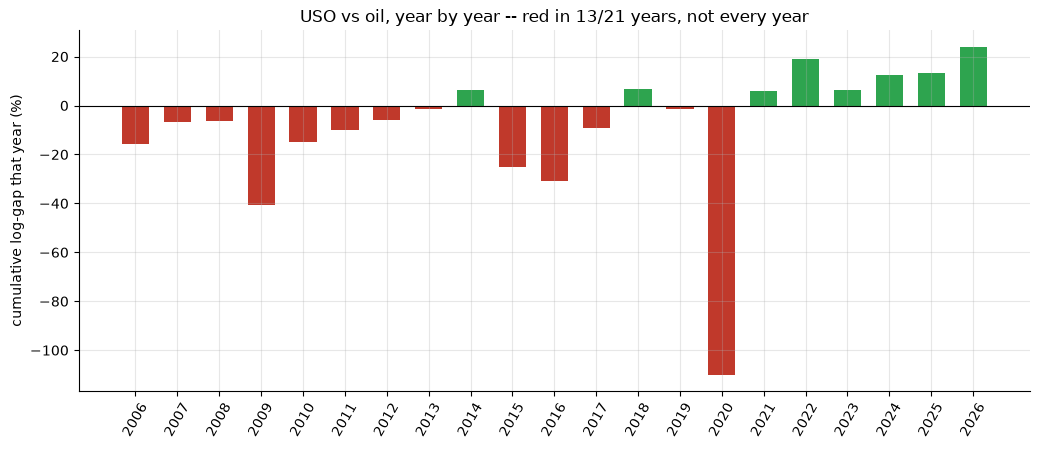

years USO underperformed: 13/21


In [4]:
if HAVE_REAL:
    yearly = DF['gap'].groupby(DF.index.year).sum() * 100
    n_neg = int((yearly < 0).sum())
else:
    yearly, n_neg = None, R['years_neg']
fig, ax = plt.subplots(figsize=(10.5, 4.6))
if yearly is not None:
    cols = [RED if v < 0 else GREEN for v in yearly.values]
    ax.bar(yearly.index.astype(str), yearly.values, color=cols, width=.65)
    ax.set_xticklabels(yearly.index.astype(str), rotation=60)
    ax.set_ylabel('cumulative log-gap that year (%)')
ax.axhline(0, c='k', lw=.8)
ax.set_title(f'USO vs oil, year by year -- red in {n_neg}/{R["years_total"]} '
             'years, not every year')
plt.tight_layout(); plt.show()
print(f'years USO underperformed: {n_neg}/{R["years_total"]}')

**13 of 21** calendar years are red — a majority, but nowhere near "every year, like clockwork." And every single year from **2021 through 2026** (5.5 years running) is green: USO gained **+229%** while CL=F gained only **+46%** — USO *beat* the oil price it supposedly bleeds against, by **+14.8%/yr**, and that gap is itself statistically real (*t* ≈ 2.5-4.5). Same mechanism, opposite sign: when the futures curve flips from contango to **backwardation** (the regime oil sat in through most of 2021-2026's supply-constrained market), the monthly roll *collects* rather than pays a toll. "USO mechanically loses to oil" isn't a standing law — it's a bet on which side of the curve the market happens to sit on, and the market has sat on the other side for over five years running.

**Now the most dramatic single day of all — April 20, 2020, when oil went negative.**

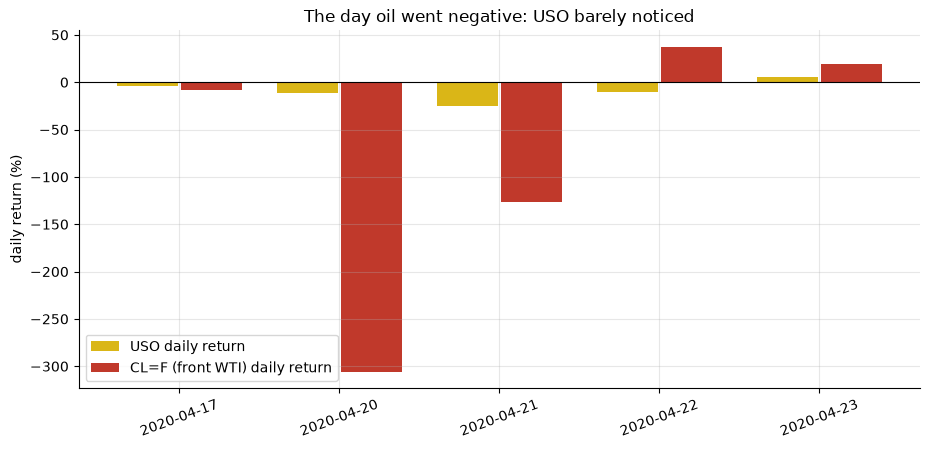

2020-04-17: USO   -3.44%   CL=F    -8.05%
2020-04-20: USO  -10.93%   CL=F  -305.97%
2020-04-21: USO  -25.07%   CL=F  -126.60%
2020-04-22: USO  -10.68%   CL=F   +37.66%
2020-04-23: USO   +5.18%   CL=F   +19.74%


In [5]:
labels = [d for d,_,_,_,_ in R['apr20']]
uso_r = [ur for _,_,ur,_,_ in R['apr20']]
clf_r = [cr for _,_,_,_,cr in R['apr20']]
fig, ax = plt.subplots(figsize=(9.4, 4.6))
x = np.arange(len(labels))
ax.bar(x-0.2, uso_r, width=0.38, color=AMBER, label='USO daily return')
ax.bar(x+0.2, clf_r, width=0.38, color=RED, label='CL=F (front WTI) daily return')
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=20)
ax.set_ylabel('daily return (%)')
ax.set_title('The day oil went negative: USO barely noticed')
ax.legend(); plt.tight_layout(); plt.show()
for d,uc,ur,cc,cr in R['apr20']:
    print(f'{d}: USO {ur:+7.2f}%   CL=F {cr:+8.2f}%')

On **2020-04-20** the front WTI contract cratered to **-$37.63** — the first negative oil price in history — a **-306%** one-day move. USO that same day: **-10.9%**. Painful, but a completely ordinary bad day, because by then USO already held a laddered basket across contract months, not the collapsing front contract alone. It still lost **40.4%** cumulatively over that week — it didn't escape the storm — but the folklore image of "USO went negative too" is simply false. The "USO = oil" mental model broke in both directions on the one day it mattered most.

**Finally: can you get paid for knowing all this?**

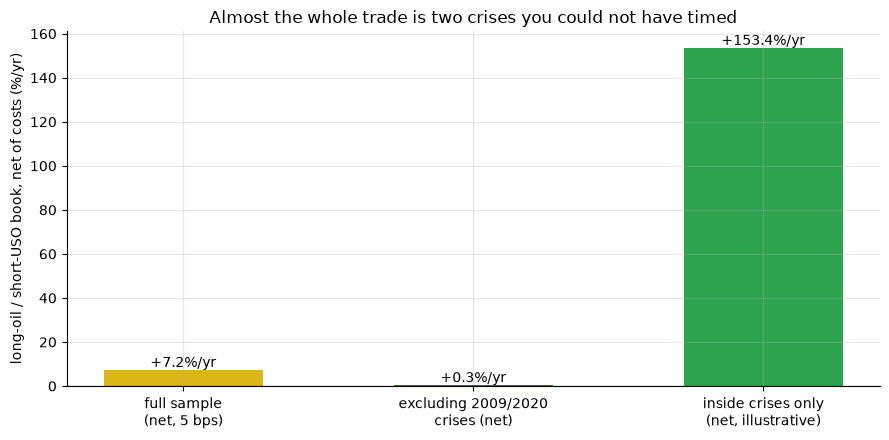

full sample net +7.17%/yr | ex-crisis +0.27%/yr | crisis-only +153.4%/yr


In [6]:
labels = ['full sample\n(net, 5 bps)', 'excluding 2009/2020\ncrises (net)',
          'inside crises only\n(net, illustrative)']
vals = [R['net5_ann'], R['ex_stress_ann'], R['stress_only_ann']]
cols = [AMBER, RED, GREEN]
fig, ax = plt.subplots(figsize=(9.0, 4.5))
ax.bar(labels, vals, color=cols, width=.55)
for i,v in enumerate(vals): ax.annotate(f'{v:+.1f}%/yr',(i,v),ha='center',
    va='bottom' if v>=0 else 'top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('long-oil / short-USO book, net of costs (%/yr)')
ax.set_title('Almost the whole trade is two crises you could not have timed')
plt.tight_layout(); plt.show()
print(f"full sample net {R['net5_ann']:+.2f}%/yr | ex-crisis {R['ex_stress_ann']:+.2f}%/yr | crisis-only {R['stress_only_ann']:+.1f}%/yr")

The full-sample trade looks decent: **+7.2%/yr** net, Sharpe 0.37. But take out the 2009 and 2020 crisis windows and the net return is **+0.27%/yr** — statistically nothing. You'd have needed to correctly hold this trade through two once-a-decade storage crises to earn anything at all; the other 95% of the time it barely covers its own costs. That's not a repeatable edge — it's a backtest that happened to straddle two rare disasters.

## 5 · The verdict

- **Signal — Weak.** USO really has lost **80%** against a flat oil price over 20 years, and two real crisis episodes (2009, 2020) really did hurt it — but that's not the same as a persistent, mechanical per-year decay. Excluding all of 2020, the daily drag is no longer statistically distinguishable from zero by the standard test (naive *t* = -1.15); year-by-year the sign splits **13/21** negative, not "almost every year"; and the most recent **5.5 years running** (2021-2026) went the *other* way, USO beating oil by **+14.8%/yr** with its own real *t*-stat. The mechanism is genuine (roll yield), but it cuts both ways with the curve's shape — it is not the one-way structural tax the folklore describes.
- **Tradability — Mirage.** The obvious "short USO, own oil futures" trade nets to roughly nothing once you remove the two crises that made it look good — and for over five years now it would have actively lost money.
- **"Does USO let you own oil?" — Busted.** Wrong direction on the 20-year magnitude, wrong again in the other direction on the most extreme single day, and wrong in a *third* direction for the last five-plus years. USO is not a spot-oil proxy in any regime.

## 6 · Going further 🚪

- **The general lesson is roll yield.** Any futures-based ETF (VXX/VIXY on vol, BITO on bitcoin, most commodity trackers) pays or collects a toll that has nothing to do with the price of the thing it's named after — read the prospectus before you assume "the fund = the asset."
- **Where the pros actually play it** is directly in the futures curve (calendar spreads, term-structure positioning) rather than through a retail ETP wrapper — the wrapper adds its own costs and structural constraints on top of the curve.
- **Sibling studies:** [100-melting-ice](../../100-melting-ice/) (the general commodity-contango story), [375-vxx-roll-decay](../../375-vxx-roll-decay/) (the same mechanism in VIX futures) and [619-bito-roll-drag](../../619-bito-roll-drag/) (the same family, bitcoin) — none of them race USO against the exact number its own holders think it tracks.

*Think the next storage crisis is coming and you can time it? That's a forecast, not a backtest — show it forward, out of sample, then we'll talk.*